In [2]:
from sctoolbox.utils.jupyter import bgcolor, _compare_version

# change the background of input cells
bgcolor("PowderBlue", select=[3, 6, 9, 11])

nb_name = "annotation.ipynb"

_compare_version(nb_name)

# Cell type annotation and marker list assembly
<hr style="border:2px solid black"> </hr>

## 1 - Description

**Requires a clustered or otherwise categorized anndata object. A clustering can be generated with a clustering notebook (e.g. `rna_analysis/notebooks/04_clustering.ipynb`).**

**Move this notebook into the notebook folder (e.g. `rna_analysis/notebooks/`) of the respective analysis before using it!**

This Jupyter Notebook is designed for annotating cell types in clustered AnnData objects. It is divided into two main parts:

- **Marker List Assembly**: This part is used when no existing marker lists are available. It enables users to assemble custom marker lists using the MarkerRepo.

- **Annotation**: This section applies the created or provided marker lists to annotate cell types in AnnData objects.


For more information about MarkerRepo, click [here](https://gitlab.gwdg.de/loosolab/software/annotate_by_marker_and_features).

--------------

## 2- Setup

In [3]:
from sctoolbox import settings
import sctoolbox.utils as utils
import sctoolbox.plotting as pl
import os
import pandas as pd
pd.set_option('display.max_columns', None)  # no limit to the number of columns shown

settings.settings_from_config("config.yaml", key="annoation")

Created directory: ../figures/annotation/
Created directory: ../tables/annotation/
Created directory: ../report/annotation/


In [4]:
try:
    import markerrepo.wrappers as wrap
    import markerrepo.marker_repo as mr
except ModuleNotFoundError:
    raise ModuleNotFoundError("Please install the latest MarkerRepo version.")
    
with pd.option_context("display.max.rows", None, "display.max_colwidth", None):
    display(utils.general.get_version_report(report="versions.yml"))

/mnt/workspace2/hschult/.conda/sctoolbox/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


,Name,Version
0,Python,"3.12.12 | packaged by conda-forge | (main, Oct 22 2025, 23:25:55) [GCC 14.3.0]"
1,markerrepo,0.1
2,numpy,2.3.5
3,sctoolbox,NA
4,pandas,2.3.3
5,anndata,0.12.6
6,scanpy,1.11.5


<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [5]:
# Set inpput anndata
clustered_adata = "anndata_marker.h5ad"

___

## 3 - Loading adata

In [6]:
adata = utils.adata.load_h5ad(clustered_adata)

[INFO] The adata object was loaded from: ../adatas/anndata_marker.h5ad


In [7]:
with pd.option_context("display.max.rows", 5, "display.max.columns", None):
    display(adata)
    display(adata.obs)

AnnData object with n_obs × n_vars = 8803 × 160363
    obs: 'sample', 'disease state', 'tissue', 'selected cell types', 'fld_score', 'mean_fragment_size', 'n_fragments', 'fold_change_promoters_fragments', 'frip', 'tsse_score', 'doublet_score', 'predicted_doublet', 'n_features', 'log1p_n_features', 'leiden', 'LISI_score_X_pca', 'LISI_score_X_umap', 'sample_density', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', '0.2_1', '0.2_2', 'clustering'
    var: 'chr', 'start', 'end', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'annotation_feature', 'gene_strand', 'gene_start', 'gene_end', 'annotation_query', 'query_name', 'distance_to_gene', 'gene_anchor', 'gene_ovl_peak', 'peak_ovl_gene', 'relative_location_to_gene', 'gene_id', 'gene_version', 'gene_name', 'gene_source', 'gene_biotype', 'highly_variable'
    uns: '0.2_1_colors', '0.2_2_colors'

,sample,disease state,tissue,selected cell types,fld_score,mean_fragment_size,n_fragments,fold_change_promoters_fragments,frip,tsse_score,doublet_score,predicted_doublet,n_features,log1p_n_features,leiden,LISI_score_X_pca,LISI_score_X_umap,sample_density,leiden_0.1,leiden_0.2,leiden_0.3,leiden_0.4,leiden_0.5,leiden_0.6,leiden_0.7,leiden_0.8,leiden_0.9,0.2_1,0.2_2,clustering
barcode,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AAACGAAAGAGAGGTA-1,sample 1,healthy,blood,PBMCs,1236.596857,131.17,55681,0.385877,0.755841,7.305137,0.048303,False,12605,9.441928,0,1.0,1.0,0.452229,1,1,1,1,1,1,1,1,1,1,1,1
AAACGAAAGCAGGAGG-1,sample 1,healthy,blood,PBMCs,1411.451173,123.53,18024,0.557725,0.764383,7.814169,0.073210,False,5392,8.592857,1,1.0,1.0,0.594502,2,2,3,4,3,3,3,4,3,5,7,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGTTCTGATCTT-1,sample 1,healthy,blood,PBMCs,1669.071202,135.55,49822,0.329239,0.692217,4.656945,0.130035,False,13992,9.546312,0,1.0,1.0,0.699981,1,10,2,3,14,2,2,3,15,1,1,1
TTTGTGTTCTTACTCA-1,sample 1,healthy,blood,PBMCs,2070.700868,144.87,51305,0.381827,0.599754,6.906920,0.341463,False,10882,9.294957,6,1.0,1.0,0.159993,7,11,10,15,15,15,17,18,16,2,4,4


___

## 4 - Essential Input
<hr style="border:2px solid black"> </hr>
Adjust the parameters shown below to enable basic cell type annotation.

### 4.1 - Parameter Overview
<hr style="border:1px solid black"> </hr>

| Parameter | Description | Options |
|-----------|-------------|--------------|
| `clustering_column` | `.obs` column used for the cell type assignment. | `None` (select interactively) or String (e.g., `"leiden"`) |
| `organism` | Specifies the organism for marker list assembly (see `4.1.1`). None to provide a custom marker list (see `marker_lists`). | `None` or String (e.g., `"human"`) |
| `marker_lists` | Use preassembled marker lists. Either a path to a directory of marker lists, paths to marker lists or None to manually assemble one. See section `4.1.2` for details. | `None` or String or list of Strings (e.g., `"/path/my_markers"` or `["/heart_markers/markers", "/human/panglao"]` |
| `repo_path` | Path to MarkerRepo. if None, the MarkerRepo will be downloaded to the notebooks folder| `None` or String |

#### 4.1.1 Available organisms
The organism of the current dataset. Will be used to assemble a marker list based on the internally provided sources. 

Currently available organisms are:

- `human`

- `mouse`

- `zebrafish`

- `rat`
 
This parameter will be ignored in favor of a custom marker list (see section `4.1.2` below). This will also cause the assembly section (`5`) to be skipped.


#### 4.1.2 - Custom marker list
Alternatively, the user can supply a custom list of marker genes by setting `marker_lists` to a user-supplied file. This has to be a **delimited text file (`.csv`, `.tsv`, ...), without a header and with two columns**. The first column contains the marker names and the second column has the cell types. For example:
```
marker_1    Fibroblast
marker_2    Fibroblast
marker_3    Endocardium
...
```

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [8]:
# Annotation settings
clustering_column = "clustering"
organism = "human"
# set path to custom marker lists
marker_lists = None

# add the path to annotate_by_marker_and_features repo
# set to None to clone the repository to your notebooks folder
repo_path = None

# Data layer (advanced)
# decide which processing state of the data should be used for computation
# available layers can be seen above, e.g. "norm" to use normalized data
# it is recommended to use raw or normalized data for statistical testing
layer = "norm"

In [9]:
# check path of MarkerRepo
if repo_path is None or not os.path.exists(repo_path):
    if not os.path.exists("./annotate_by_marker_and_features"):
        print("MarkerRepo was not found! Cloning repository...")
        !git clone https://gitlab.gwdg.de/loosolab/software/annotate_by_marker_and_features.git
    else:
        print("MarkerRepo was found! Changing path to <./annotate_by_marker_and_features>")
    repo_path = "./annotate_by_marker_and_features"

MarkerRepo was not found! Cloning repository...
Cloning into 'annotate_by_marker_and_features'...
remote: Enumerating objects: 2433, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 2433 (delta 54), reused 0 (delta 0), pack-reused 2331 (from 1)
Receiving objects: 100% (2433/2433), 73.79 MiB | 7.25 MiB/s, done.
Resolving deltas: 100% (1523/1523), done.


--------------

## 5 - Marker List Assembly
<hr style="border:2px solid black"> </hr>

The marker list paths are stored in the <b>marker_lists</b> variable. They work as input for the actual cell type annotation of the next cell.

### 5.1 - Parameter Overview
<hr style="border:1px solid black"> </hr>

| Parameter | Description | Options |
|-----------|-------------|---------|
| `search_terms` | Search terms for the marker list assembly, targeting specific columns. | `None` or Dictionary (e.g., `{"Source": "panglao.se", "Tissue", "Heart"}`) |
| `list_format` | Additional parameters for marker list assembly. One marker list is created per dictionary. | `None` or List of dictionaries (e.g., `[{"style":"two_column", "file_name":"two_column"}, {"style":"score", "file_name":"score"}]`|

**Recommendation:** Set `search_terms` and `list_format` to `None` this enables an interactive guide to assemble the marker list. Manually setting `search_terms` and `list_format` is mostly intended for advanced users who already know what to search for.

#### 5.1.1 search_terms (advanced)
Each `key:value` pair will narrow the search in the marker list database to target specific lists, for example, setting `"Organism name": "human"` will ensure the use of marker lists relevant to the selected organism. Multiple search terms will be connected with a logical `AND` e.g. `"Organism name": "human", "Tissue": "blood"` will only consider human marker genes of blood during list assembly.

**Run the following cell to see available input(s) for `search_terms`.**

#### 5.1.2 list_format (advanced)
The `list_format` parameter decides the method and format of the resulting annotation list. Each dictionary entry will result in a marker list, which will be saved locally as a separate annotation list.

| Key | Value | Description |
|-----|-------|-------------|
| `file_name` | `None` or filename | The file where the finished list will be stored. Set `None` or skip entry to set the name interactively. |
| `style` | One of `two_column`, `score` or `ui` | The style of the marker lists. Either a minimal list of gene to cell type assignments (`two_column`), a list including a score (average count of a marker gene across all lists, to measure specificity of markers to a cell type) (`score`) or a list where each gene is weighted by the ubiquitousness index (see below). |

>[The] **ubiquitousness index** (UI), [...] is an indicator of how often the gene is expressed in cell clusters. UI takes values between 0 and 1. Values toward 1 indicate the gene is expressed in more cell clusters, indicating the gene to be involved in housekeeping tasks.

[Franzén et al., 2019](https://doi.org/10.1093/database/baz046)

**List of available inputs for `search_terms`**

In [10]:
if not marker_lists and not organism:
    raise ValueError("Please provide either <organism> or a path to custom marker list <marker_lists>")
if not marker_lists:
    df = mr.search_df(df=mr.combine_dfs(repo_path=repo_path), col_to_search="Organism name", search_terms=[f"+{organism.split(' ')[0]}"])
    print(f"* Possible keys for <column_specific_terms>:\n {df.columns.to_list()}\n")
    for col in df.columns[:12]:
        print(f"* Possible values for {col}: {df[col].dropna().drop_duplicates().to_list()}\n")

* Possible keys for <column_specific_terms>:
 ['List name', 'Marker type', 'Organism name', 'Taxonomy ID', 'Submitter name', 'List type', 'Source', 'tags_transferred', 'Date', 'Email', 'Tissue', 'Life stage', 'tags_info', 'tags_age', 'Marker', 'Info']

* Possible values for List name: ['HCM_human_fetus', 'human_gender_genes', 'Panglao_human_skin', 'Panglao_human_lungs', 'Panglao_human_na', 'HCM_human_adipose-tissue', 'HCM_human_arthrosis', 'HCM_human_brain', 'HCM_human_cerebral-organoid', 'HCM_human_genitals', 'HCM_human_epithelium', 'human_mito_genes', 'Panglao_human_thymus', 'Panglao_human_urinary-bladder', 'Panglao_human_smooth-muscle', 'Panglao_human_gi-tract', 'Panglao_human_blood', 'Panglao_human_epithelium', 'Panglao_human_olfactory-system', 'Panglao_human_vasculature', 'human_cellcycle_genes', 'Panglao_human_zygote', 'Panglao_human_adrenal-glands', 'Panglao_human_heart', 'Human_mito', 'Panglao_human_thyroid', 'Panglao_human_oral-cavity', 'Panglao_human_liver', 'Panglao_human_pa

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [11]:
# Marker list assembly
if not marker_lists:
    # we recommend specifying "Tissue" if possible to get more accurate results
    search_terms = {"Organism name": organism, "Tissue": ["blood", "immune-system"]}

    list_format = [{"file_name":"symbol", "style":"two_column"},
                   {"file_name":"score", "style":"score"},
                   {"file_name":"ui", "style":"ui"}
                  ]

___

In [12]:
if not marker_lists:
    marker_lists = wrap.create_multiple_marker_lists(
        cml_parameters=list_format,
        repo_path=repo_path,
        organism=organism,
        ensembl=mr.check_ensembl(adata),
        column_specific_terms=search_terms,
        show_lists=True,
        path=settings.table_dir
    )

Found 88 marker lists for the given organism human.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Date,Email,Tissue,Life stage,tags_info,tags_age,Marker,Info
ID,,,,,,,,,,,,,,,,
1688745545837,HCM_human_fetus,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,fetus,NaN,NaN,NaN,"[CD4, ENSG00000010610, EMCN, ENSG00000164035, ...","[T cell, Natural killer cell, Stromal cell, Im..."
17083323392210,human_gender_genes,Genes,human,9606,"Kessler, Micha Frederick",Gender,sctoolbox,NaN,NaN,Micha-Frederick.Kessler@mpi-bn.mpg.de,NaN,NaN,NaN,NaN,"[MTND6P13, ENSG00000234901, HMGN1P37, ENSG0000...",[Gender genes]
168874554211252,Panglao_human_skin,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,skin,NaN,NaN,NaN,"[PTPRC, ENSG00000081237, CLDN1, ENSG0000016334...","[Merkel cells, Sebocytes, Trichocytes, Melanoc..."
168874554264756,Panglao_human_lungs,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,lung,NaN,NaN,NaN,"[RAB3D, ENSG00000105514, G0S2, ENSG00000123689...","[Pulmonary alveolar type I cells, Ionocytes, C..."
168874554292179,Panglao_human_na,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,na,NaN,NaN,NaN,"[SPN, ENSG00000197471, CALD1, ENSG00000122786,...","[Pluripotent stem cells, T cells naive, Glomus..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1688745545683176,HCM_human_esophageal,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,esophagus,NaN,NaN,NaN,"[SOX2, ENSG00000181449]",[Esophageal squamous cell]
1688745545764487,HCM_human_gingiva,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,gingiva,NaN,NaN,NaN,"[ITGB1, ENSG00000150093, THY1, ENSG00000154096...",[Mesenchymal stem cell]
1688745545897512,HCM_human_head-and-neck,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,head-and-neck,NaN,NaN,NaN,"[CD3E, ENSG00000198851, CD44, ENSG00000026508,...","[Cancer stem cell, Mesenchymal cell, Conventio..."


Found 4 marker lists for the given search terms.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Date,Email,Tissue,Life stage,tags_info,tags_age,Marker,Info
ID,,,,,,,,,,,,,,,,
1688745542154410,Panglao_human_blood,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,blood,NaN,NaN,NaN,"[WIPF1, ENSG00000115935, AHSG, ENSG00000145192...","[Platelets, Reticulocytes, Erythroid-like and ..."
1688745542679837,Panglao_human_immune-system,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,immune-system,NaN,NaN,NaN,"[SOCS1, ENSG00000185338, BCL6, ENSG00000113916...","[B cells naive, Mast cells, Eosinophils, T mem..."
1688745543601880,HCM_human_blood-vessel,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,blood-vessel,NaN,NaN,NaN,"[ANPEP, ENSG00000166825, PTPRC, ENSG0000008123...","[Endocrine cell, Endothelial stem cell, Choroi..."
1688745544415178,HCM_human_blood,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,blood,NaN,NaN,NaN,"[SPRR3, ENSG00000163209, CDK12, ENSG0000016725...","[M2 microglial cell, White blood cell, CD56+ n..."


Preparing two column style marker list...
Marker list saved: /mnt/workspace2/hschult/sc-framework-paper/Code_Schultheis_et_al_2025_SC-Framework/ATAC/analysis/01-analysis-run/tables/annotation/symbol
Found 88 marker lists for the given organism human.


...

Preparing score style marker list...
Marker list saved: /mnt/workspace2/hschult/sc-framework-paper/Code_Schultheis_et_al_2025_SC-Framework/ATAC/analysis/01-analysis-run/tables/annotation/score
Found 88 marker lists for the given organism human.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Date,Email,Tissue,Life stage,tags_info,tags_age,Marker,Info
ID,,,,,,,,,,,,,,,,
1688745545837,HCM_human_fetus,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,fetus,NaN,NaN,NaN,"[CD4, ENSG00000010610, EMCN, ENSG00000164035, ...","[T cell, Natural killer cell, Stromal cell, Im..."
17083323392210,human_gender_genes,Genes,human,9606,"Kessler, Micha Frederick",Gender,sctoolbox,NaN,NaN,Micha-Frederick.Kessler@mpi-bn.mpg.de,NaN,NaN,NaN,NaN,"[MTND6P13, ENSG00000234901, HMGN1P37, ENSG0000...",[Gender genes]
168874554211252,Panglao_human_skin,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,skin,NaN,NaN,NaN,"[PTPRC, ENSG00000081237, CLDN1, ENSG0000016334...","[Merkel cells, Sebocytes, Trichocytes, Melanoc..."
168874554264756,Panglao_human_lungs,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,lung,NaN,NaN,NaN,"[RAB3D, ENSG00000105514, G0S2, ENSG00000123689...","[Pulmonary alveolar type I cells, Ionocytes, C..."
168874554292179,Panglao_human_na,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,na,NaN,NaN,NaN,"[SPN, ENSG00000197471, CALD1, ENSG00000122786,...","[Pluripotent stem cells, T cells naive, Glomus..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1688745545683176,HCM_human_esophageal,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,esophagus,NaN,NaN,NaN,"[SOX2, ENSG00000181449]",[Esophageal squamous cell]
1688745545764487,HCM_human_gingiva,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,gingiva,NaN,NaN,NaN,"[ITGB1, ENSG00000150093, THY1, ENSG00000154096...",[Mesenchymal stem cell]
1688745545897512,HCM_human_head-and-neck,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,head-and-neck,NaN,NaN,NaN,"[CD3E, ENSG00000198851, CD44, ENSG00000026508,...","[Cancer stem cell, Mesenchymal cell, Conventio..."


Found 4 marker lists for the given search terms.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Date,Email,Tissue,Life stage,tags_info,tags_age,Marker,Info
ID,,,,,,,,,,,,,,,,
1688745542154410,Panglao_human_blood,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,blood,NaN,NaN,NaN,"[WIPF1, ENSG00000115935, AHSG, ENSG00000145192...","[Platelets, Reticulocytes, Erythroid-like and ..."
1688745542679837,Panglao_human_immune-system,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,immune-system,NaN,NaN,NaN,"[SOCS1, ENSG00000185338, BCL6, ENSG00000113916...","[B cells naive, Mast cells, Eosinophils, T mem..."
1688745543601880,HCM_human_blood-vessel,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,blood-vessel,NaN,NaN,NaN,"[ANPEP, ENSG00000166825, PTPRC, ENSG0000008123...","[Endocrine cell, Endothelial stem cell, Choroi..."
1688745544415178,HCM_human_blood,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,blood,NaN,NaN,NaN,"[SPRR3, ENSG00000163209, CDK12, ENSG0000016725...","[M2 microglial cell, White blood cell, CD56+ n..."


Preparing ui style marker list...
Directory does not exist. Cloning the whitelist repository...
Repository cloned.
Marker list saved: /mnt/workspace2/hschult/sc-framework-paper/Code_Schultheis_et_al_2025_SC-Framework/ATAC/analysis/01-analysis-run/tables/annotation/ui


--------------

## 6 - Annotate adata
<hr style="border:2px solid black"> </hr>
After selection and creation of the gene marker lists, potential cell types can be annotated in this final step. This notebook supports two methods of annotation, MarkerRepo and SCSA.

### 6.1 - Parameter Overview

| Parameter | Description | Options/Type |
|-----------|-------------|--------------|
| `marker_repo` | Use [MarkerRepo](https://gitlab.gwdg.de/loosolab/software/annotate_by_marker_and_features) for annotation. | Boolean |
| `SCSA` | Use [SCSA](https://github.com/bioinfo-ibms-pumc/SCSA) for annotation. | Boolean |
| `mr_obs` | Prefix of the MarkerRepo annotation columns added to `anndata.obs`. | String (e.g., "mr") |
| `scsa_obs` | Prefix of the SCSA annotation columns added to `anndata.obs`. | String (e.g., "scsa") |
| `rank_genes_column` | **Advanced users only** Column of `.uns` table with rank genes scores. If `None`, the ranking will be performed on the clustering_column. | `None` or String |
| `reference_obs` | A reference annotation in `.obs` for comparison. See section `3 - Loading adata` for possible values. | `None` or String |
| `min_hits` | The minimum number of marker matches needed to annotate a cluster. May be lowered in case of small marker lists. | Integer |

<h1><center>⬐ Fill in input data here ⬎</center></h1>

In [13]:
marker_repo = True
SCSA = True
mr_obs = "MR"
scsa_obs = "SCSA"
rank_genes_column = "rank_feature_clustering_filtered"
reference_obs = None
min_hits = 5

___

In [14]:
compare_df = wrap.run_annotation(adata,
                                 marker_repo=marker_repo,
                                 SCSA=SCSA,
                                 marker_lists=marker_lists,
                                 mr_obs=mr_obs,
                                 scsa_obs=scsa_obs,
                                 rank_genes_column=rank_genes_column,
                                 clustering_column=clustering_column,
                                 reference_obs=reference_obs,
                                 show_comparison=True,
                                 ignore_overwrite=True,
                                 show_plots=False,
                                 output_path=settings.table_dir,
                                 min_hits=min_hits
                                )
_ = pl.general.plot_table(compare_df, crop=None, report='01_Comparison_of_cell_type_annotations.png', col_width=7)

Comparison of cell type annotations:


,MR_symbol_clustering,SCSA_symbol_clustering,MR_score_clustering,SCSA_score_clustering,MR_ui_clustering,SCSA_ui_clustering
clustering,,,,,,
1,CD1C-CD141- dendritic cell,CD1C-CD141- dendritic cell,CD1C-CD141- dendritic cell,CD1C-CD141- dendritic cell,CD1C-CD141- dendritic cell,CD1C-CD141- dendritic cell
2,CD4+ recently activated effector memory or eff...,NK cells,Effector CD8+ memory T (Tem) cell,NK cells,Effector CD8+ memory T (Tem) cell,NK cells
3,Central memory CD8+ T cell,Naive CD8+ T cell,Multilymphoid progenitor cell,Naive CD8+ T cell,Naive CD8+ T cell,Naive CD8+ T cell
4,Activated CD8+ T cell,Natural killer cell,AXL+SIGLEC6+ dendritic cell,Natural killer cell,AXL+SIGLEC6+ dendritic cell,Natural killer cell
5,CD1C-CD141- dendritic cell,CD1C-CD141- dendritic cell,CD1C-CD141- dendritic cell,CD1C-CD141- dendritic cell,CD1C-CD141- dendritic cell,CD1C-CD141- dendritic cell
6,CD1C-CD141- dendritic cell,CD1C-CD141- dendritic cell,Multilymphoid progenitor cell,CD1C-CD141- dendritic cell,Multilymphoid progenitor cell,CD1C-CD141- dendritic cell
7,Central memory CD4+ T cell,Regulatory T (Treg) cell,Multilymphoid progenitor cell,Regulatory T (Treg) cell,Multilymphoid progenitor cell,Regulatory T (Treg) cell
8,B cells,B cells,CD141+CLEC9A+ dendritic cell,B cells,B cells,B cells
9,NK cells,NK cells,Multilymphoid progenitor cell,NK cells,T cell,NK cells


In [15]:
# rename NK cells to Natural killer cell
# they are separate entries due to inconsistent names within marker lists
for col in compare_df.columns:
    adata.obs[col] = ["Natural killer cell" if val == "NK cells" else val for val in adata.obs[col]]

[INFO] Saving figure to ../figures/annotation/marker_genes_dots_clustering.pdf


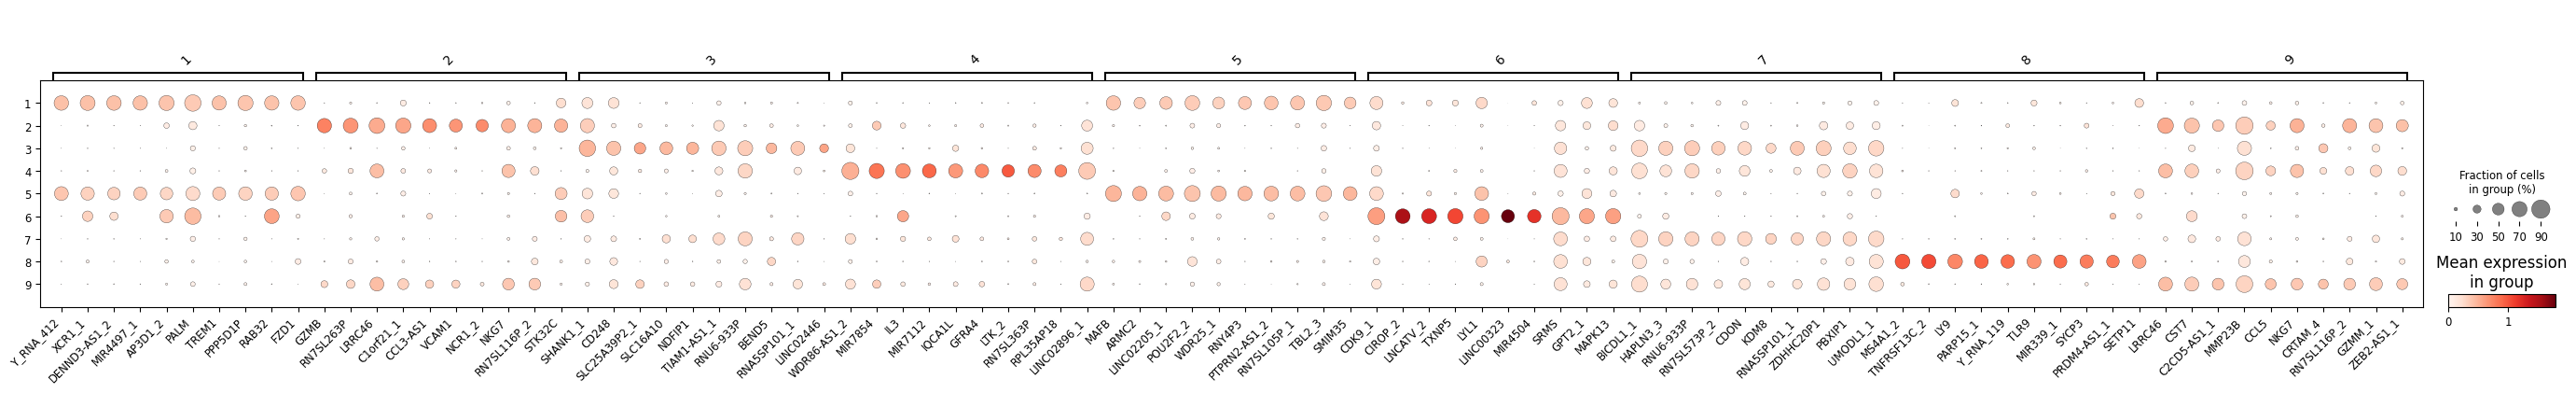

In [16]:
if not rank_genes_column:
    rank_genes_column = f"rank_genes_groups_{clustering_column}"

# Plot dotplot of markers
_ = pl.marker_genes.rank_genes_plot(
    adata,
    key=rank_genes_column,
    n_genes=10,
    style="dots",
    save=f"marker_genes_dots_{clustering_column}.pdf",
    layer=layer,
    report=f"01_marker_genes_dots_{clustering_column}.png"
)

[INFO] Saving figure to ../figures/annotation/compare_annotations.pdf


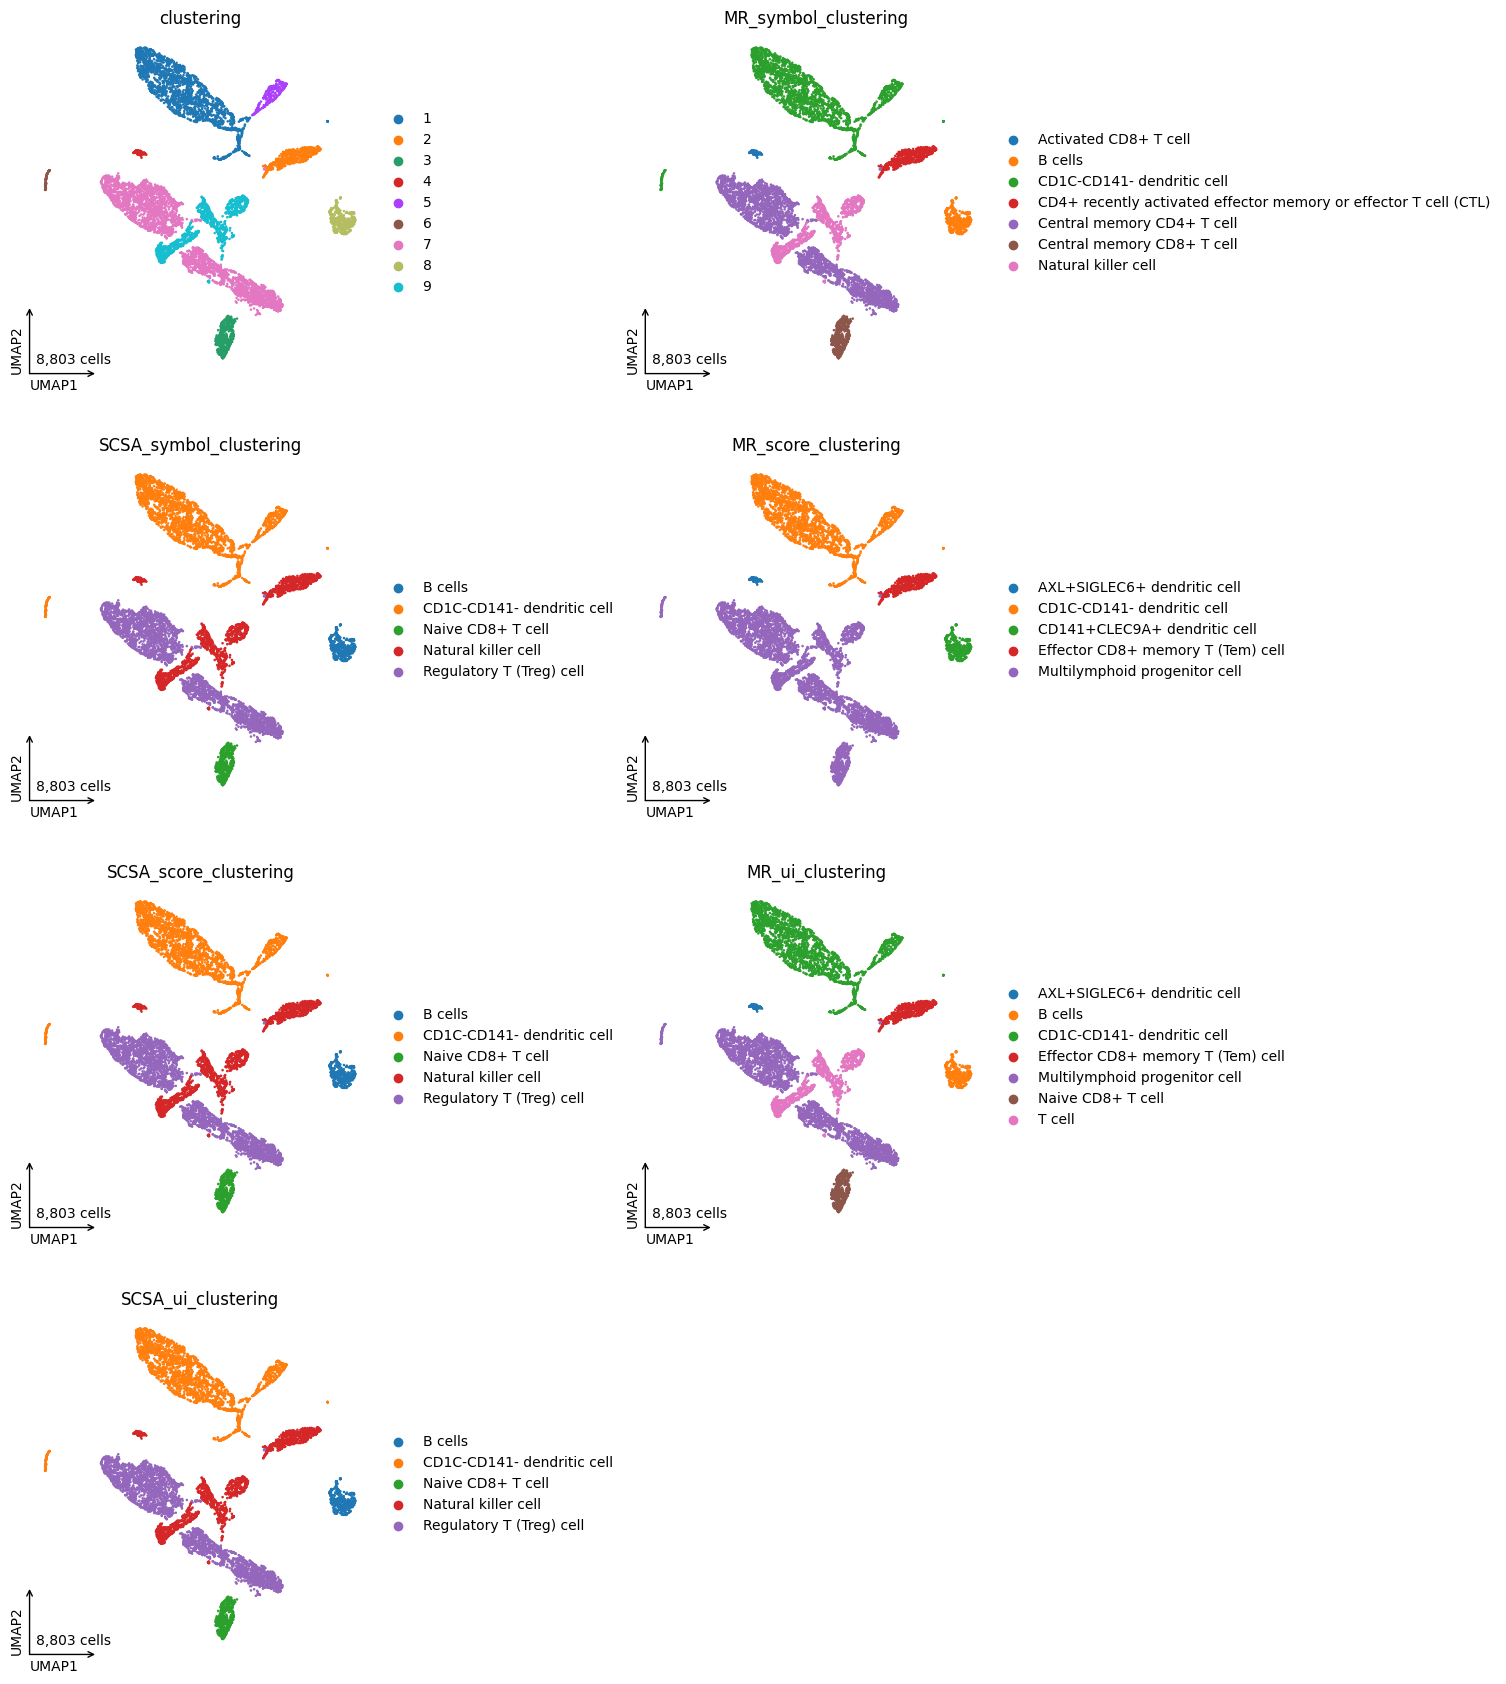

In [17]:
# Plot cell type annotations
columns = [clustering_column] + list(compare_df.columns)
_ = pl.embedding.plot_embedding(adata, method="umap", color=columns, ncols=2,
                                save="compare_annotations.pdf", report="02_compare_annotations.png")

[INFO] Saving figure to ../figures/annotation/cell_distribution_barplot.png


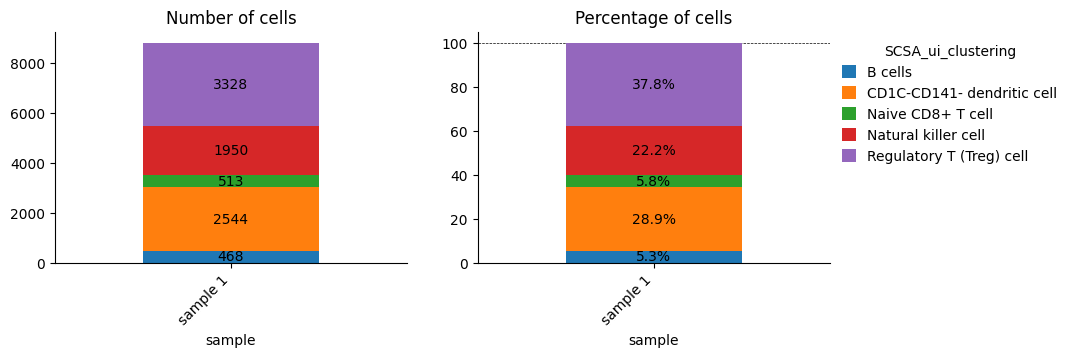

In [18]:
_ = pl.qc_filter.n_cells_barplot(
    adata,
    groupby=col,
    x="sample",
    add_labels=True,
    save="cell_distribution_barplot.png"
)

--------------

### 6.1 - Show annotated .obs table

In [19]:
display(adata.obs)

,sample,disease state,tissue,selected cell types,fld_score,mean_fragment_size,n_fragments,fold_change_promoters_fragments,frip,tsse_score,doublet_score,predicted_doublet,n_features,log1p_n_features,leiden,LISI_score_X_pca,LISI_score_X_umap,sample_density,leiden_0.1,leiden_0.2,leiden_0.3,leiden_0.4,leiden_0.5,leiden_0.6,leiden_0.7,leiden_0.8,leiden_0.9,0.2_1,0.2_2,clustering,MR_symbol_clustering,SCSA_symbol_clustering,MR_score_clustering,SCSA_score_clustering,MR_ui_clustering,SCSA_ui_clustering
barcode,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AAACGAAAGAGAGGTA-1,sample 1,healthy,blood,PBMCs,1236.596857,131.17,55681,0.385877,0.755841,7.305137,0.048303,False,12605,9.441928,0,1.0,1.0,0.452229,1,1,1,1,1,1,1,1,1,1,1,1,CD1C-CD141- dendritic cell,CD1C-CD141- dendritic cell,CD1C-CD141- dendritic cell,CD1C-CD141- dendritic cell,CD1C-CD141- dendritic cell,CD1C-CD141- dendritic cell
AAACGAAAGCAGGAGG-1,sample 1,healthy,blood,PBMCs,1411.451173,123.53,18024,0.557725,0.764383,7.814169,0.073210,False,5392,8.592857,1,1.0,1.0,0.594502,2,2,3,4,3,3,3,4,3,5,7,7,Central memory CD4+ T cell,Regulatory T (Treg) cell,Multilymphoid progenitor cell,Regulatory T (Treg) cell,Multilymphoid progenitor cell,Regulatory T (Treg) cell
AAACGAAAGGAAGAAC-1,sample 1,healthy,blood,PBMCs,1782.208350,139.17,59175,0.407774,0.671787,5.600357,0.017122,False,13306,9.496045,2,1.0,1.0,0.430152,3,3,4,5,4,4,4,6,4,6,8,8,B cells,B cells,CD141+CLEC9A+ dendritic cell,B cells,B cells,B cells
AAACGAAAGTCGACCC-1,sample 1,healthy,blood,PBMCs,1730.228578,133.49,67838,0.438864,0.722881,7.603606,0.272727,False,14049,9.550378,3,1.0,1.0,0.845933,4,4,5,6,5,5,5,7,5,7,7,7,Central memory CD4+ T cell,Regulatory T (Treg) cell,Multilymphoid progenitor cell,Regulatory T (Treg) cell,Multilymphoid progenitor cell,Regulatory T (Treg) cell
AAACGAACAAGCGGTA-1,sample 1,healthy,blood,PBMCs,2187.394361,151.19,75125,0.365714,0.603991,6.049748,0.040581,False,14514,9.582938,4,1.0,1.0,0.365009,5,7,7,8,8,7,6,10,8,10,2,2,CD4+ recently activated effector memory or eff...,Natural killer cell,Effector CD8+ memory T (Tem) cell,Natural killer cell,Effector CD8+ memory T (Tem) cell,Natural killer cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGTTCGTCAACA-1,sample 1,healthy,blood,PBMCs,1668.157785,132.82,36613,0.466419,0.708519,7.549431,0.251418,False,9291,9.136909,3,1.0,1.0,0.668766,4,4,6,7,5,5,16,17,18,7,7,7,Central memory CD4+ T cell,Regulatory T (Treg) cell,Multilymphoid progenitor cell,Regulatory T (Treg) cell,Multilymphoid progenitor cell,Regulatory T (Treg) cell
TTTGTGTTCTATCTCA-1,sample 1,healthy,blood,PBMCs,1693.156089,141.87,39058,0.452239,0.671727,8.035019,0.061674,False,9423,9.151015,4,1.0,1.0,0.455072,5,7,7,8,8,7,6,10,8,10,2,2,CD4+ recently activated effector memory or eff...,Natural killer cell,Effector CD8+ memory T (Tem) cell,Natural killer cell,Effector CD8+ memory T (Tem) cell,Natural killer cell
TTTGTGTTCTCTATTG-1,sample 1,healthy,blood,PBMCs,1744.062999,131.21,54291,0.419093,0.650955,6.274450,0.080851,False,11109,9.315601,6,1.0,1.0,0.338171,7,6,9,10,10,9,8,12,10,9,9,9,Natural killer cell,Natural killer cell,Multilymphoid progenitor cell,Natural killer cell,T cell,Natural killer cell


--------------

## 7 - Save adata

In [20]:
utils.io.update_yaml({"annotation": True}, "method.yml", path_prefix="report")
utils.adata.save_h5ad(adata, "anndata_annotated.h5ad")

[INFO] The adata object was saved to: ../adatas/anndata_annotated.h5ad
